# Lorenz-96 Assimilation Time vs N

Read runtime archives produced by `scripts/test_runtime.sh` and plot per-step assimilation time versus ensemble size. EnKF/LETKF use the runtime archive; IEnKF uses the same source-selection logic as `L96_metric_curves.ipynb`, then reads assimilation time and ES from the matching `output_records_*.pt` files.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'test_notebooks':
    REPO_ROOT = REPO_ROOT.parent

RUNTIME_BASE = REPO_ROOT / 'save' / 'runtime_test'
runtime_dirs = sorted(RUNTIME_BASE.glob('lorenz96_*'))
if not runtime_dirs:
    raise FileNotFoundError(f'No Lorenz-96 ML runtime archive found under {RUNTIME_BASE}')

# Change this to a specific Path(...) if you want to plot an older ML runtime run.
RUNTIME_ROOT = runtime_dirs[-1]
MANIFEST_PATH = RUNTIME_ROOT / 'manifest.tsv'
BENCHMARK_ROOT = REPO_ROOT / 'save' / 'benchmark_lorenz96'
CLASSIC_SIGMA_Y = '1.0'

FIG_SAVE_DIR = REPO_ROOT / 'save' / 'figures' / 'l96_runtime'
FIG_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f'RUNTIME_ROOT = {RUNTIME_ROOT}')
print(f'MANIFEST_PATH = {MANIFEST_PATH}')
print(f'BENCHMARK_ROOT = {BENCHMARK_ROOT}')

RUNTIME_ROOT = /home/bhchen/LearnKalmanGain/save/runtime_test/lorenz96_20260514_134343
MANIFEST_PATH = /home/bhchen/LearnKalmanGain/save/runtime_test/lorenz96_20260514_134343/manifest.tsv
BENCHMARK_ROOT = /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96


In [12]:
# Color assignment copied from the combined L96 metric-curve notebook.
COMBINED_L63_COLOR_ORDER = [
    'ESRF',
    'EnKF',
    'IEnKF',
    'EtE + ES',
    'CorrTerms+ES',
    'EtE + NL2',
    'CorrTerms+NL2',
    'LETKF',
]
COMBINED_COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
COMBINED_METHOD_COLORS = {
    label: COMBINED_COLOR_CYCLE[i % len(COMBINED_COLOR_CYCLE)]
    for i, label in enumerate(COMBINED_L63_COLOR_ORDER)
}

METHOD_LABELS = {
    'CorrTerms': 'CorrTerms',
    'EtE-LRes': 'EtE-LRes',
    'EnKF': 'EnKF',
    'LETKF': 'LETKF',
    'IEnKF': 'IEnKF',
}
METHOD_COLORS = {
    'CorrTerms': COMBINED_METHOD_COLORS['CorrTerms+ES'],
    'EtE-LRes': COMBINED_METHOD_COLORS['EtE + ES'],
    'EnKF': COMBINED_METHOD_COLORS['EnKF'],
    'LETKF': COMBINED_METHOD_COLORS['LETKF'],
    'IEnKF': COMBINED_METHOD_COLORS['IEnKF'],
}
METHOD_ORDER = ['CorrTerms', 'EtE-LRes', 'EnKF', 'LETKF', 'IEnKF']
ML_METHODS = ['CorrTerms', 'EtE-LRes']
CLASSIC_METHODS = ['EnKF', 'LETKF', 'IEnKF']
IENKF_SOURCE_METHODS = ['iEnKS-PertObs', 'iEnKS-Sqrt']
N_LIST = [5, 10, 15, 20, 40, 60, 100]
DEVICE_ORDER = {'cpu': 0, 'cuda': 1}
DEVICE_LINESTYLES = {'cpu': '-', 'cuda': '--'}
DEVICE_LABELS = {'cpu': 'CPU', 'cuda': 'GPU'}

In [13]:
def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')


def record_value(record_dict, key):
    if not isinstance(record_dict, dict):
        return np.nan
    for base in [record_dict.get('test_results', {}), record_dict.get('nn', {}), record_dict]:
        if isinstance(base, dict) and key in base and base[key] is not None:
            try:
                return float(base[key])
            except Exception:
                return np.nan
    return np.nan


def load_runtime_record(record_path: Path):
    if not record_path.exists():
        return None
    record = safe_torch_load(record_path)
    assim_step_time_s = record_value(record, 'mean_assim_time')
    if not np.isfinite(assim_step_time_s):
        assim_step_time_s = record_value(record, 'assim_step_time_mean')
    assim_step_time_weighted_s = record_value(record, 'mean_assim_time_w')
    if not np.isfinite(assim_step_time_weighted_s):
        assim_step_time_weighted_s = record_value(record, 'assim_step_time_mean_weighted')
    return {
        'runtime_s': record_value(record, 'time'),
        'mean_es1': record_value(record, 'mean_es1'),
        'valid_percent': record_value(record, 'valid_percent'),
        'assim_step_time_s': assim_step_time_s,
        'assim_step_time_ms': 1000.0 * assim_step_time_s,
        'assim_step_time_weighted_s': assim_step_time_weighted_s,
        'assim_step_time_weighted_ms': 1000.0 * assim_step_time_weighted_s,
    }


def load_ml_runtime_record(archive_dir: Path, n_value: int):
    candidates = sorted(archive_dir.glob(f'output_records_{n_value}*.pt'))
    if not candidates:
        return None, None
    record_path = candidates[-1]
    return record_path, load_runtime_record(record_path)


def collect_runtime_table(manifest_path: Path):
    manifest = pd.read_csv(manifest_path, sep='\t')
    rows = []
    for row in manifest.itertuples(index=False):
        if row.method == 'iEnKS-PertObs':
            # IEnKF is sourced below using the same benchmark selection logic as L96_metric_curves.
            continue
        archive_dir = REPO_ROOT / row.archive_dir
        record_path, loaded = load_ml_runtime_record(archive_dir, int(row.N))
        if loaded is None:
            print(f'[warn] missing output record: {archive_dir}')
            continue
        rows.append({
            'kind': row.kind,
            'method': row.method,
            'label': METHOD_LABELS.get(row.method, row.method),
            'device': row.device,
            'N': int(row.N),
            'sigma_y': str(row.sigma_y),
            'obs_fn': row.obs_fn,
            'source_method': row.method,
            'record_path': record_path,
            **loaded,
        })
    return rows


def metric_source_has_all_finite_es(folder: Path):
    if not folder.exists():
        return False
    for n_value in N_LIST:
        loaded = load_runtime_record(folder / f'output_records_{n_value}.pt')
        if loaded is None or not np.isfinite(loaded['mean_es1']):
            return False
    return True


def select_ienkf_metric_source():
    pertobs_dir = BENCHMARK_ROOT / f'benchmark_lorenz96_{CLASSIC_SIGMA_Y}_iEnKS-PertObs'
    sqrt_dir = BENCHMARK_ROOT / f'benchmark_lorenz96_{CLASSIC_SIGMA_Y}_iEnKS-Sqrt'
    if metric_source_has_all_finite_es(pertobs_dir):
        return pertobs_dir, 'iEnKS-PertObs'
    if sqrt_dir.exists():
        return sqrt_dir, 'iEnKS-Sqrt'
    if pertobs_dir.exists():
        return pertobs_dir, 'iEnKS-PertObs'
    return None, None


def collect_ienkf_metric_runtime_table():
    source_dir, source_method = select_ienkf_metric_source()
    if source_dir is None:
        print('[warn] no IEnKF benchmark source found.')
        return []
    print(f'IEnKF source: {source_method} | {source_dir}')
    rows = []
    for n_value in N_LIST:
        record_path = source_dir / f'output_records_{n_value}.pt'
        loaded = load_runtime_record(record_path)
        if loaded is None:
            print(f'[warn] missing IEnKF output record: {record_path}')
            continue
        if not np.isfinite(loaded['mean_es1']):
            print(f'[skip] IEnKF ES is NaN for N={n_value}: {record_path}')
            continue
        rows.append({
            'kind': 'classic',
            'method': 'IEnKF',
            'label': f'IEnKF ({source_method})',
            'device': 'cpu',
            'N': int(n_value),
            'sigma_y': CLASSIC_SIGMA_Y,
            'obs_fn': 'default',
            'source_method': source_method,
            'record_path': record_path,
            **loaded,
        })
    return rows


runtime_df = pd.DataFrame(collect_runtime_table(MANIFEST_PATH) + collect_ienkf_metric_runtime_table())
if runtime_df.empty:
    raise RuntimeError('No runtime records were loaded.')
runtime_df = runtime_df[np.isfinite(runtime_df['mean_es1'])].copy()
runtime_df['method_order'] = runtime_df['method'].map({m: i for i, m in enumerate(METHOD_ORDER)}).fillna(999)
runtime_df['device_order'] = runtime_df['device'].map(DEVICE_ORDER).fillna(999)
runtime_df = runtime_df.sort_values(['method_order', 'device_order', 'N']).reset_index(drop=True)
runtime_df[['kind', 'method', 'source_method', 'device', 'sigma_y', 'N', 'assim_step_time_ms', 'mean_es1', 'valid_percent']].head(12)

IEnKF source: iEnKS-Sqrt | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_iEnKS-Sqrt
[skip] IEnKF ES is NaN for N=5: /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_iEnKS-Sqrt/output_records_5.pt
[skip] IEnKF ES is NaN for N=10: /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_iEnKS-Sqrt/output_records_10.pt
[skip] IEnKF ES is NaN for N=15: /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_iEnKS-Sqrt/output_records_15.pt
[skip] IEnKF ES is NaN for N=40: /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_iEnKS-Sqrt/output_records_40.pt
[skip] IEnKF ES is NaN for N=60: /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_iEnKS-Sqrt/output_records_60.pt


,kind,method,source_method,device,sigma_y,N,assim_step_time_ms,mean_es1,valid_percent
0,ml,CorrTerms,CorrTerms,cpu,1.0,5,5.220648,32.709431,100.0
1,ml,CorrTerms,CorrTerms,cpu,1.0,10,5.581458,33.701519,100.0
2,ml,CorrTerms,CorrTerms,cpu,1.0,15,5.877505,33.969921,100.0
3,ml,CorrTerms,CorrTerms,cpu,1.0,20,7.438319,33.037605,100.0
4,ml,CorrTerms,CorrTerms,cpu,1.0,40,7.954036,26.365086,100.0
5,ml,CorrTerms,CorrTerms,cpu,1.0,60,11.216204,20.857166,100.0
6,ml,CorrTerms,CorrTerms,cpu,1.0,100,14.791903,11.808293,100.0
7,ml,CorrTerms,CorrTerms,cuda,1.0,5,3.501379,32.734131,100.0
8,ml,CorrTerms,CorrTerms,cuda,1.0,10,3.362334,33.574852,100.0
9,ml,CorrTerms,CorrTerms,cuda,1.0,15,3.426654,34.012230,100.0


In [14]:
display(runtime_df.pivot_table(index='N', columns=['method', 'device'], values='assim_step_time_ms'))

# Diagnostic table for the IEnKF source records selected with the L96_metric_curves logic.
runtime_df[runtime_df['method'] == 'IEnKF'][['N', 'assim_step_time_ms', 'mean_es1', 'valid_percent', 'source_method', 'record_path']]

method  CorrTerms                 EnKF   EtE-LRes                  IEnKF  \
device        cpu      cuda        cpu        cpu      cuda          cpu   
N                                                                          
5        5.220648  3.501379   3.669727   5.077455  2.761958          NaN   
10       5.581458  3.362334   4.331325   4.884710  2.590380          NaN   
15       5.877505  3.426654   5.234470   5.754973  2.669752          NaN   
20       7.438319  3.375599   5.202174   5.602536  2.632507  1554.140857   
40       7.954036  3.765244   6.697853   8.145677  2.629582          NaN   
60      11.216204  3.457551   8.870678   9.585251  2.677431          NaN   
100     14.791903  3.383723  11.603649  14.137094  2.592923  3727.636443   

method       LETKF  
device         cpu  
N                   
5        35.119532  
10       61.106140  
15       84.473247  
20      110.928018  
40      278.586296  
60      468.604167  
100     893.528901

,N,assim_step_time_ms,mean_es1,valid_percent,source_method,record_path
42,20,1554.140857,12.142825,1.5625,iEnKS-Sqrt,/home/bhchen/LearnKalmanGain/save/benchmark_lo...
43,100,3727.636443,11.238097,1.5625,iEnKS-Sqrt,/home/bhchen/LearnKalmanGain/save/benchmark_lo...


Saved: /home/bhchen/LearnKalmanGain/save/figures/l96_runtime/L96_assim_time_vs_N.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/l96_runtime/L96_assim_time_vs_N.pdf


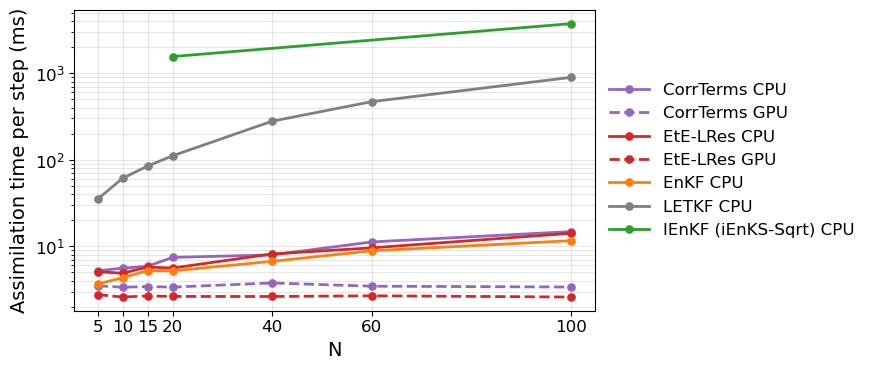

In [15]:
def plot_assim_time_vs_n(df, time_col='assim_step_time_ms', out_stem='L96_assim_time_vs_N'):
    fig, ax = plt.subplots(figsize=(10.8, 3.8))

    for method in METHOD_ORDER:
        method_df = df[df['method'] == method]
        if method_df.empty:
            continue
        color = METHOD_COLORS.get(method)
        for device in ['cpu', 'cuda']:
            curve = method_df[method_df['device'] == device].sort_values('N')
            curve = curve[np.isfinite(curve[time_col]) & (curve[time_col] > 0)]
            if curve.empty:
                continue
            label_base = curve['label'].iloc[0] if 'label' in curve else METHOD_LABELS.get(method, method)
            ax.plot(
                curve['N'],
                curve[time_col],
                marker='o',
                linewidth=2.0,
                markersize=5.2,
                linestyle=DEVICE_LINESTYLES.get(device, '-'),
                color=color,
                label=f"{label_base} {DEVICE_LABELS.get(device, device)}",
            )

    ax.set_xlabel('N', fontsize=14)
    ax.set_ylabel('Assimilation time per step (ms)', fontsize=14)
    ax.set_yscale('log')
    ax.set_xticks(sorted(df['N'].unique()))
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(alpha=0.3, which='both')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles,
        labels,
        loc='center left',
        bbox_to_anchor=(1.015, 0.5),
        frameon=False,
        fontsize=12,
        handlelength=2.4,
        borderaxespad=0.0,
    )
    fig.tight_layout(rect=[0, 0, 0.82, 1])

    png_path = FIG_SAVE_DIR / f'{out_stem}.png'
    pdf_path = FIG_SAVE_DIR / f'{out_stem}.pdf'
    fig.savefig(png_path, dpi=180, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f'Saved: {png_path}')
    print(f'Saved: {pdf_path}')
    plt.show()
    return fig


fig = plot_assim_time_vs_n(runtime_df)